## How many senses does the cell have? 

Goal: Take mutagenesis data and construct a mapping so that if expression levels of various genes are known, environment can be recovered. 

Approach 1: Apply PCA to a matrix containing expression data for clusters of cells from different environments. 

Appraoch 2: Look at natural variation, where high variation at a binding site indicates that that binding site is not in use. 

Approach 3: Bayesian Inference.

Starting with "Approach 1." First, construct a matrix to perform PCA on. Say there are $m$ different genes and $n$ different conditions. Specify a batch count, $\nu$, which is the number of batches the sequence collection will be divided into, for each environment. This matrix will have $\nu n$ rows and $m$ columns. The entries will be expression data for 

In [73]:
import os
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random

import equinox as eqx

from promdis.processing import get_sequence_arrays_and_counts, gene_seq_to_array
from promdis.jax.core import compute_mean_expression_shift
from promdis.jax.core import compute_expression_shift_by_mutation
from promdis.jax.core import compute_expression_shift_by_pairwise_mutation
from promdis.jax.core import compare_sequences
from promdis.pl import plot_data_2d


In [74]:
#Specify a bactch count
nu = 100
size = int(1000/nu)  

In [75]:

OUTDIR = "../results/epistasis"
os.makedirs(OUTDIR, exist_ok=True)

SEED = None
rng = np.random.default_rng(seed=SEED)

with open('../data/gene_list.txt', 'r') as file:
    # Read lines into a list
    genes = file.readlines()
    
with open('../data/condition_list.txt', 'r') as file:
    # Read lines into a list
    conditions = file.readlines()
    


In [76]:
data = np.zeros((nu*len(conditions), len(genes)))


for GENE in genes:
    for COND in conditions:
        GENE0 = GENE.replace('\n', '')
        COND0 = COND.replace('\n','')
        
        FPATH = f"../data/regseq_data/{GENE0}{COND0}dataset_alldone_with_large"
        
        # Check if the file exists
        if not os.path.exists(FPATH):
            print(f"File not found: {FPATH}")
            continue


        df = pd.read_csv(FPATH, sep='\\s+')
        df['barcode'] = df['seq'].str.slice(160,)
        df['promoter'] = df['seq'].str.slice(0, 160)

        seqs, counts_dna, counts_rna = get_sequence_arrays_and_counts(
            df, key_promoter='promoter', key_rna='ct_1', key_dna='ct_0'
        )

        expression = counts_rna / (counts_dna + counts_rna)
        
        for k in range(nu):
            sample = random.sample(range(len(expression)), size)
            selected_exp = [expression[i] for i in sample]
            data[k + nu*conditions.index(COND)][genes.index(GENE)] = np.sum(selected_exp) / len(selected_exp)
            
            



File not found: ../data/regseq_data/yagH0cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/yagH500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/eco0cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/eco500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/ecoTredataset_alldone_with_large
File not found: ../data/regseq_data/ycgB500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/ydhO500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/ymgG500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/ygeR500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/yggW500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/mscL500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/dpiBA500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/adiY500cAMPdataset_alldone_with_large


In [83]:
for row in data:
    print(row)

[0.         0.07884615 0.         0.16521739 0.         0.04285714
 0.         0.025      0.12727273 0.025      0.         0.2
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.075
 0.1        0.         0.05555556 0.         0.         0.16714286
 0.         0.         0.2        0.11875    0.11875    0.
 0.09166667 0.         0.025      0.06666667 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.15       0.         0.         0.05789474 0.
 0.05217391 0.         0.11809955 0.         0.         0.04
 0.         0.         0.         0.         0.21382353 0.22433761
 0.2        0.         0.18571429 0.         0.         0.18888889
 0.         0.         0.         0.         0.1        0.08
 0.1        0.175      0.         0.06666667 0.         0.01818182
 0.1        0.028      0.27638889 0.         0.09090909 0.1
 0.06666667 0.17295345 0.06666667 0.         0.         0.
 0.    

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


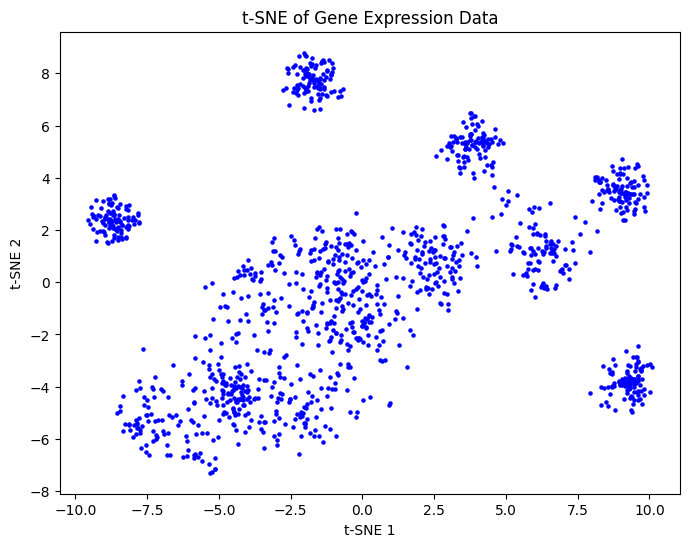

In [80]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(data)

tsne_df = pd.DataFrame(data=tsne_results, columns=['t-SNE1', 't-SNE2'])

plt.figure(figsize=(8, 6))
plt.scatter(tsne_df['t-SNE1'], tsne_df['t-SNE2'], color = 'blue', s = 5)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of Gene Expression Data')
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


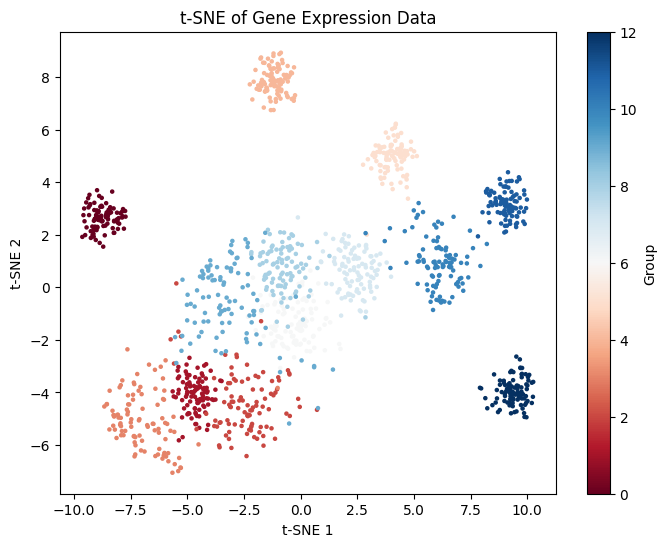

In [82]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np



num_cells = data.shape[0]
num_groups = num_cells // nu


group_labels = np.repeat(range(num_groups), nu)


tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(data)


tsne_df = pd.DataFrame(data=tsne_results, columns=['t-SNE1', 't-SNE2'])
tsne_df['Group'] = group_labels


plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_df['t-SNE1'], tsne_df['t-SNE2'], c=tsne_df['Group'], cmap='RdBu', s = 5)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of Gene Expression Data')
plt.colorbar(scatter, label='Group')
plt.show()

In [78]:
print(random.sample(range(len(expression)), int(size)))
print(size)

[10168, 16548, 11806, 13450, 9212, 13655, 10416, 15333, 15476, 8381]
10
